In [3]:
import cv2 as cv
import numpy as np

In [15]:
img = cv.imread('Resources/Photos/park.jpg')
cv.imshow("Img", img)
cv.waitKey(0)
cv.destroyAllWindows()

### Convert to grayscale

In [16]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# side_by_side = cv.hconcat([img, gray])

cv.imshow("Img_gray", gray)
cv.imshow("Img", img)


cv.waitKey(0)
cv.destroyAllWindows()

### blurring img

Of course. Here is a detailed breakdown of the parameters for `cv.GaussianBlur`, including a correction for the small mistake in your code snippet.

### `cv.GaussianBlur()` Explained

This function applies a Gaussian blur to an image. It's a very common way to reduce image noise and detail by averaging out pixel values with their neighbors, giving more weight to closer pixels.

Here's the function signature and an explanation of its parameters:

`cv.GaussianBlur(src, ksize, sigmaX, sigmaY=None, borderType=None)`

-----

#### **1. `src` (Source Image)**

  * **Your code:** `img`
  * **What it is:** This is simply the input image you want to blur. It should be a NumPy array, which is what `cv.imread()` provides.

-----

#### **2. `ksize` (Kernel Size)**

  * **Your code:** `ksize=(3,3)`
  * **What it is:** This is the size of the blurring "kernel" or matrix that moves across the image.
      * It **must be a tuple of two positive, odd integers**, like `(3, 3)`, `(5, 5)`, `(7, 7)`, etc.
      * A larger kernel size (e.g., `(7, 7)`) will result in a **more intense blur** because it averages pixel values over a larger area. A smaller size like `(3, 3)` creates a more subtle blur.

-----

#### **3. `sigmaX` (Standard Deviation in X)**

  * **Your code:** `sigmaX=cv.BORDER_DEFAULT` **(This is incorrect)**
  * **What it is:** This is the standard deviation of the Gaussian function in the horizontal (X) direction. It controls how the "bell curve" of the blur is shaped.
      * A higher `sigmaX` value means the blur is more spread out.
      * **The common practice is to set this value to `0`**. When you set `sigmaX` to `0`, OpenCV automatically calculates the ideal standard deviation based on your kernel size (`ksize`). This is usually what you want.

-----

#### **4. `sigmaY` (Standard Deviation in Y) - Optional**

  * **Your code:** Not specified.
  * **What it is:** The standard deviation in the vertical (Y) direction. If you leave it unspecified (as is common), it will automatically be set to be the same as `sigmaX`.

-----

#### **5. `borderType` (Border Type) - Optional**

  * **Your code:** Not specified, but you used its value incorrectly.
  * **What it is:** This parameter tells OpenCV how to handle the pixels at the very edge of the image where the kernel doesn't have a full set of neighbors.
      * `cv.BORDER_DEFAULT` is the default setting, which typically reflects the border. You usually don't need to change this.

### Corrected Code

Here is how your line should be written to work correctly:

```python
# The sigmaX parameter should be 0 to let OpenCV calculate the optimal value.
blur = cv.GaussianBlur(img, ksize=(3,3), sigmaX=0) 
```

In [22]:
blur = cv.GaussianBlur(img, ksize=(3,3), sigmaX=cv.BORDER_DEFAULT)
cv.imshow("Img", blur)
cv.waitKey(0)
cv.destroyAllWindows()

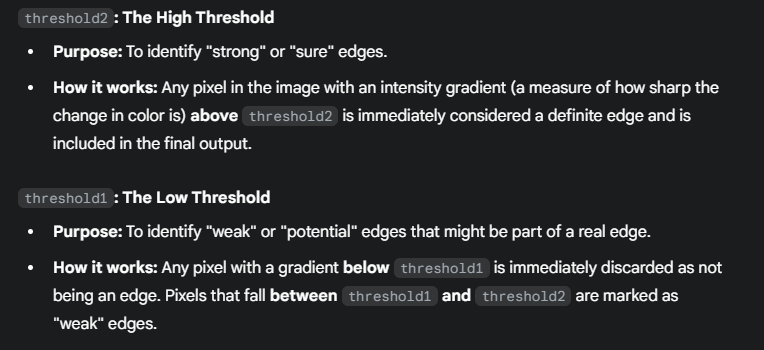

In [24]:
blur = cv.Canny(img, threshold1=125, threshold2=175)
cv.imshow("Img", blur)
cv.waitKey(0)
cv.destroyAllWindows()

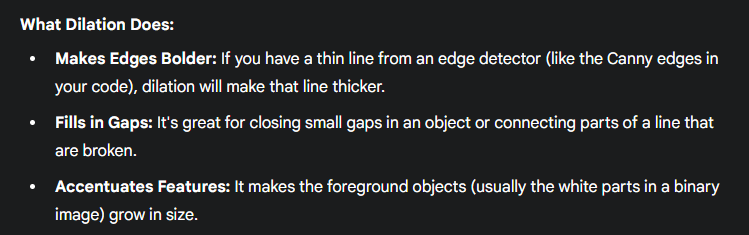

Of course. Here is the content from the guide:

### **1. Reading, Writing, and Displaying**

These are the absolute basics for getting images and videos into and out of your program.

| Function | Key Parameters | Description |
|---|---|---|
| `cv2.imread()` | `filename`, `flags` | Loads an image from a specified file path. `flags` determines the color type (e.g., `cv2.IMREAD_GRAYSCALE`). |
| `cv2.imshow()` | `winname`, `mat` | Displays an image (`mat`) in a window with a specific name (`winname`). |
| `cv2.imwrite()` | `filename`, `img` | Saves an image (`img`) to a specified file path (`filename`). |
| `cv2.VideoCapture()` | `index` or `filename` | Creates a capture object to read from a camera (`index`) or a video file (`filename`). |
| `cv2.waitKey()` | `delay` | Waits for a key press for a specified number of milliseconds (`delay`). If `0`, it waits indefinitely. |
| `cv2.destroyAllWindows()` | (None) | Closes all open windows created by OpenCV. |

### **2. Basic Image Transformations**

Functions for common manipulations like resizing, rotating, and drawing.

| Function | Key Parameters | Description |
|---|---|---|
| `cv2.resize()` | `src`, `dsize`, `interpolation` | Resizes the source image (`src`) to a specific size (`dsize`). `interpolation` is the method used for resizing. |
| `cv2.cvtColor()` | `src`, `code` | Converts an image (`src`) from one color space to another using a specific conversion `code` (e.g., `cv2.COLOR_BGR2GRAY`). |
| `cv2.flip()` | `src`, `flipCode` | Flips an image (`src`). `flipCode` determines the direction (0 for vertical, 1 for horizontal, -1 for both). |
| `cv2.rotate()` | `src`, `rotateCode` | Rotates an image (`src`) using a specific rotation `code` (e.g., `cv2.ROTATE_90_CLOCKWISE`). |
| `cv2.rectangle()` | `img`, `pt1`, `pt2`, `color`, `thickness` | Draws a rectangle on an image (`img`) from point 1 (`pt1`) to point 2 (`pt2`). |
| `cv2.circle()` | `img`, `center`, `radius`, `color`, `thickness` | Draws a circle on an image (`img`) with a given `center` and `radius`. |
| `cv2.line()` | `img`, `pt1`, `pt2`, `color`, `thickness` | Draws a line segment on an image (`img`) from point 1 (`pt1`) to point 2 (`pt2`). |
| `cv2.putText()` | `img`, `text`, `org`, `fontFace`, `fontScale`, `color` | Puts text on an image (`img`) at a specific origin (`org`). |

### **3. Image Processing & Filtering**

These functions are used to process images to reduce noise, enhance features, or prepare them for further analysis.

| Function | Key Parameters | Description |
|---|---|---|
| `cv2.GaussianBlur()` | `src`, `ksize`, `sigmaX` | Blurs an image (`src`) using a Gaussian filter with a kernel size (`ksize`) and standard deviation (`sigmaX`). |
| `cv2.medianBlur()` | `src`, `ksize` | Blurs an image (`src`) using the median of pixels in a kernel of a given size (`ksize`). |
| `cv2.Canny()` | `image`, `threshold1`, `threshold2` | Finds edges in an `image` using the Canny algorithm with two thresholds for hysteresis. |
| `cv2.threshold()` | `src`, `thresh`, `maxval`, `type` | Applies a fixed-level threshold to an image (`src`) to create a binary result. |
| `cv2.adaptiveThreshold()` | `src`, `maxValue`, `adaptiveMethod`, `blockSize` | Applies a variable threshold to an image (`src`) based on local pixel neighborhoods. |

### **4. Morphological Transformations**

These are operations that modify image shapes, typically performed on binary images.

| Function | Key Parameters | Description |
|---|---|---|
| `cv2.dilate()` | `src`, `kernel`, `iterations` | Expands bright regions of an image (`src`) using a specific `kernel` for a number of `iterations`. |
| `cv2.erode()` | `src`, `kernel`, `iterations` | Shrinks bright regions of an image (`src`) using a specific `kernel` for a number of `iterations`. |
| `cv2.morphologyEx()` | `src`, `op`, `kernel` | Performs advanced morphological operations (`op`) like "Opening" or "Closing" on an image (`src`). |

### **5. Contours and Shape Analysis**

Functions for finding, analyzing, and drawing the outlines of objects.

| Function | Key Parameters | Description |
|---|---|---|
| `cv2.findContours()` | `image`, `mode`, `method` | Finds contours in a binary `image`. `mode` and `method` control the retrieval hierarchy and approximation. |
| `cv2.drawContours()` | `image`, `contours`, `contourIdx`, `color`, `thickness` | Draws contours on an `image`. `contourIdx` specifies which contour to draw (-1 for all). |
| `cv2.contourArea()` | `contour` | Calculates the area of a specific `contour`. |
| `cv2.arcLength()` | `curve`, `closed` | Calculates the perimeter of a `curve` (contour). `closed` indicates if the contour is closed. |
| `cv2.boundingRect()` | `array` | Calculates the upright bounding rectangle of a contour (`array`). |

### **6. Image Cropping & Manipulation**

Advanced operations for selecting regions of interest (ROI) and manipulating pixels.

| Technique/Function | Key Parameters | Description |
|---|---|---|
| **Cropping (Slicing)** | `img[y1:y2, x1:x2]` | Extracts a rectangular region of an image using NumPy array slicing. |
| `cv2.bitwise_and()` | `src1`, `src2`, `mask` | Performs a bitwise AND operation between two images (`src1`, `src2`), often using a `mask`. |
| `cv2.bitwise_or()` | `src1`, `src2`, `mask` | Performs a bitwise OR operation. |
| `cv2.bitwise_not()` | `src`, `mask` | Inverts every bit of an image (`src`). |
| `cv2.bitwise_xor()` | `src1`, `src2`, `mask` | Performs a bitwise XOR operation. |
| `cv2.add()` | `src1`, `src2` | Adds the pixel values of two images (`src1`, `src2`) together. |
| `cv2.addWeighted()` | `src1`, `alpha`, `src2`, `beta`, `gamma` | Blends two images (`src1`, `src2`) together using specified weights (`alpha`, `beta`). |